### Basic Summary and Target Distribution

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
df = pd.read_csv('../data/raw/vocal_gender_features_new.csv')
df.head()

,mean_spectral_centroid,std_spectral_centroid,mean_spectral_bandwidth,std_spectral_bandwidth,mean_spectral_contrast,mean_spectral_flatness,mean_spectral_rolloff,zero_crossing_rate,rms_energy,mean_pitch,...,mfcc_9_std,mfcc_10_mean,mfcc_10_std,mfcc_11_mean,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,label
0,2247.331739,1158.537748,1870.415462,370.405241,21.440710,0.036879,4419.438073,0.169241,0.082552,1592.1033,...,21.736240,2.303085,8.983318,-17.410305,9.115154,0.301804,10.452693,-3.080832,10.146248,0
1,1790.719889,996.554825,1757.898617,410.710318,21.513383,0.018936,3635.742188,0.108068,0.055477,1112.6351,...,13.937135,-0.953942,10.831742,-0.088775,10.297690,-7.281142,10.926579,-0.450248,8.489134,0
2,1977.923363,1010.148667,1747.099555,461.458379,20.476283,0.032616,3873.291016,0.144633,0.060388,1557.5225,...,14.900779,0.260098,14.031009,-0.420670,10.810292,-0.199829,11.986182,3.372986,9.285437,0
3,2037.765550,1311.440630,1745.224852,419.056484,19.516014,0.028482,3826.584507,0.148933,0.029559,1481.0868,...,15.957924,-1.486122,14.461978,-8.479608,12.550333,3.997028,9.912608,-6.946966,10.574301,0
4,1739.383829,1092.623322,1623.135563,450.088465,20.260620,0.025737,3452.903892,0.117961,0.069078,1424.5352,...,15.105562,-3.366364,13.943447,-6.561539,11.944948,1.410639,13.110976,-3.252258,9.866687,0


### Basic Info

In [3]:
# Display shape and basic info
print("Dataset Shape:", df.shape)
print("\nData Types and Non-Null Counts:\n")
print(df.info())

Dataset Shape: (16148, 44)

Data Types and Non-Null Counts:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16148 entries, 0 to 16147
Data columns (total 44 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean_spectral_centroid   16148 non-null  float64
 1   std_spectral_centroid    16148 non-null  float64
 2   mean_spectral_bandwidth  16148 non-null  float64
 3   std_spectral_bandwidth   16148 non-null  float64
 4   mean_spectral_contrast   16148 non-null  float64
 5   mean_spectral_flatness   16148 non-null  float64
 6   mean_spectral_rolloff    16148 non-null  float64
 7   zero_crossing_rate       16148 non-null  float64
 8   rms_energy               16148 non-null  float64
 9   mean_pitch               16148 non-null  float64
 10  min_pitch                16148 non-null  float64
 11  max_pitch                16148 non-null  float64
 12  std_pitch                16148 non-null  float64
 13  spectral_skew  

In [4]:
# Display basic statistics
print("\nSummary Statistics:\n")
print(df.describe().T)


Summary Statistics:

                           count         mean         std          min  \
mean_spectral_centroid   16148.0  1709.269730  315.558063   719.559285   
std_spectral_centroid    16148.0  1027.564673  286.303662   194.998983   
mean_spectral_bandwidth  16148.0  1584.195931  126.360465  1106.939002   
std_spectral_bandwidth   16148.0   432.492328   78.723202   199.321584   
mean_spectral_contrast   16148.0    20.395652    1.628596    15.154801   
mean_spectral_flatness   16148.0     0.023086    0.010027     0.001816   
mean_spectral_rolloff    16148.0  3281.808257  526.824341  1310.661765   
zero_crossing_rate       16148.0     0.118088    0.037707     0.027727   
rms_energy               16148.0     0.084759    0.022814     0.022425   
mean_pitch               16148.0  1461.624198  287.763342   359.391170   
min_pitch                16148.0   153.523952    1.447309   152.343750   
max_pitch                16148.0  3981.378958   83.832598  1794.782000   
std_pitch       

In [5]:
# Check the distribution of the target variable (label: 0 = Female, 1 = Male)
print("\nLabel Distribution:\n")
print(df['label'].value_counts())


Label Distribution:

label
1    10380
0     5768
Name: count, dtype: int64


C:\Users\shubh\AppData\Local\Temp\ipykernel_17280\1671973578.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label', palette='Set2')


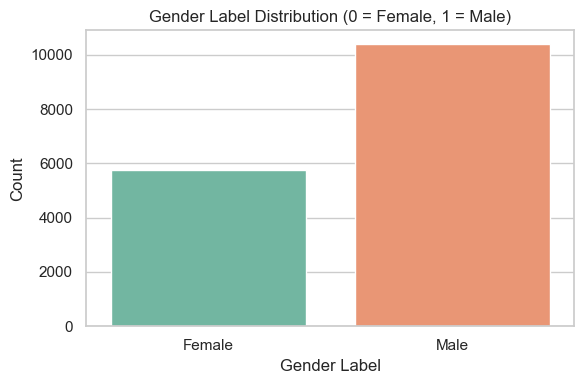

<Figure size 1000x600 with 0 Axes>

In [6]:
# Plot label distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', palette='Set2')
plt.title('Gender Label Distribution (0 = Female, 1 = Male)')
plt.xlabel('Gender Label')
plt.ylabel('Count')
plt.xticks([0, 1], ['Female', 'Male'])
plt.tight_layout()
plt.show()
plt.savefig("../reports/figures/genderLabelDist.png")

### Data Cleaning and Correlation Heatmap

In [7]:
# Check for missing values
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

mean_spectral_centroid     0
std_spectral_centroid      0
mean_spectral_bandwidth    0
std_spectral_bandwidth     0
mean_spectral_contrast     0
mean_spectral_flatness     0
mean_spectral_rolloff      0
zero_crossing_rate         0
rms_energy                 0
mean_pitch                 0
min_pitch                  0
max_pitch                  0
std_pitch                  0
spectral_skew              0
spectral_kurtosis          0
energy_entropy             0
log_energy                 0
mfcc_1_mean                0
mfcc_1_std                 0
mfcc_2_mean                0
mfcc_2_std                 0
mfcc_3_mean                0
mfcc_3_std                 0
mfcc_4_mean                0
mfcc_4_std                 0
mfcc_5_mean                0
mfcc_5_std                 0
mfcc_6_mean                0
mfcc_6_std                 0
mfcc_7_mean                0
mfcc_7_std                 0
mfcc_8_mean                0
mfcc_8_std                 0
mfcc_9_mean               

In [ ]:
# df = df.dropna()

In [8]:
# Check for duplicates
num_duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {num_duplicates}")


Number of duplicate rows: 1078


In [9]:
# Remove duplicates if any
if num_duplicates > 0:
    df = df.drop_duplicates()
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found.")

Duplicates removed. New shape: (15070, 44)


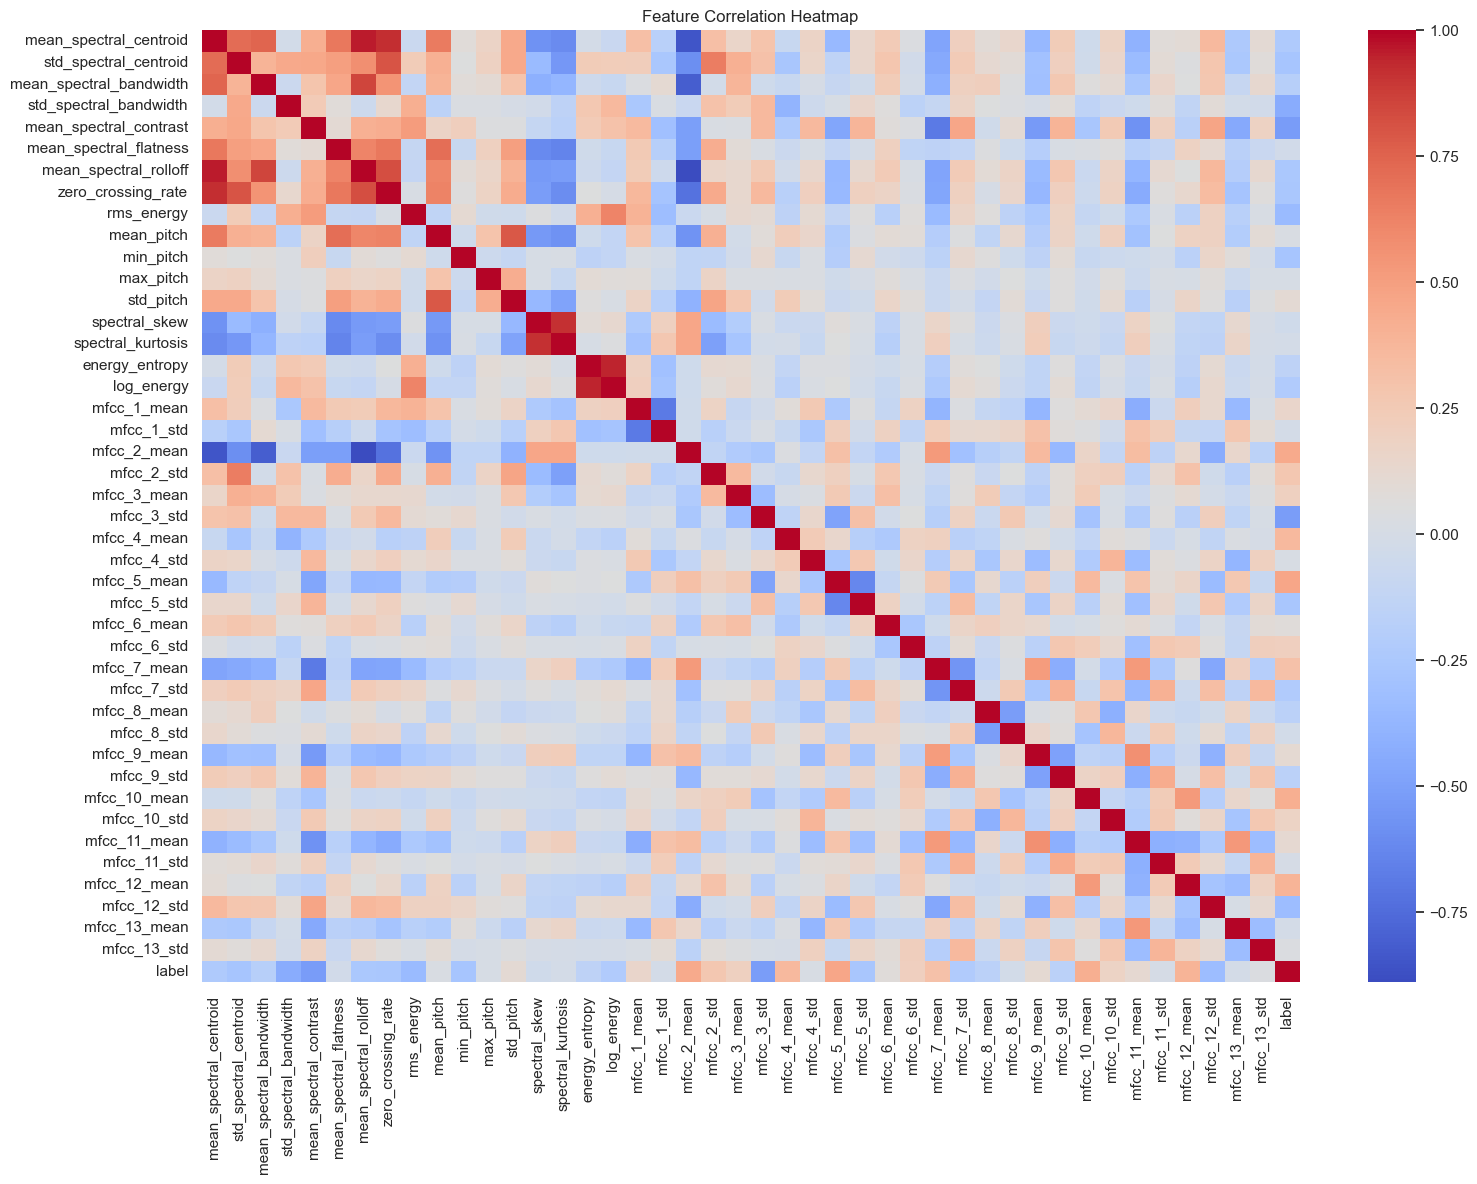

<Figure size 1000x600 with 0 Axes>

In [10]:
# 3. Correlation Heatmap (numeric features only)
plt.figure(figsize=(16, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()
plt.savefig("../reports/figures/corrHeatMap.png")

### Feature Distribution Visualization

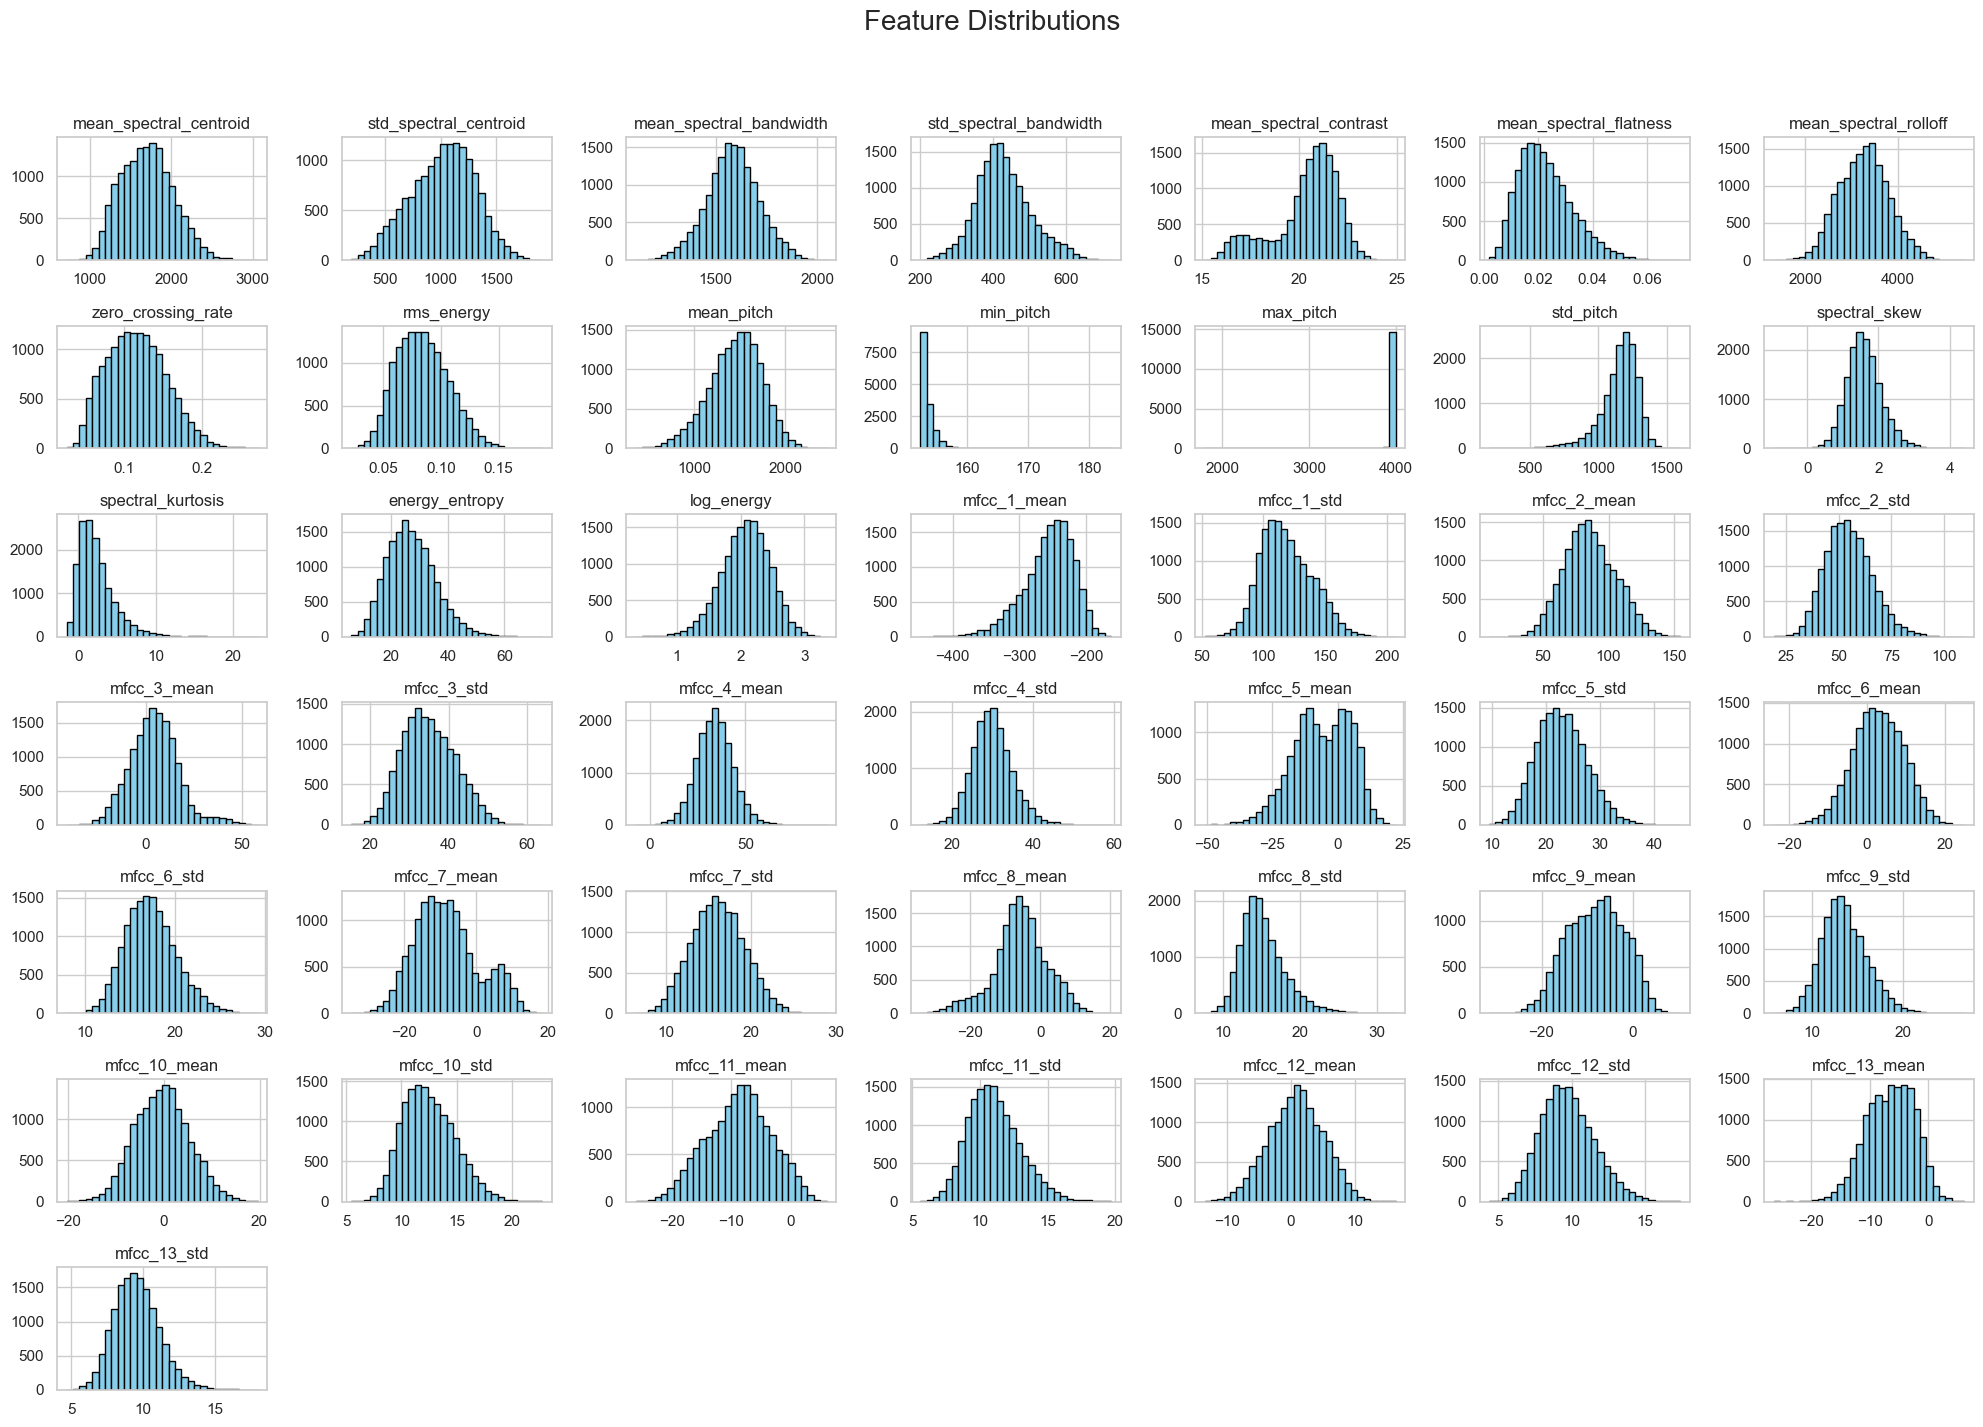

<Figure size 1000x600 with 0 Axes>

In [11]:
# Histogram of all features
df.drop('label', axis=1).hist(figsize=(20, 15), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=20)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
plt.savefig("../reports/figures/featureDist.png")

### Correlation Heatmap

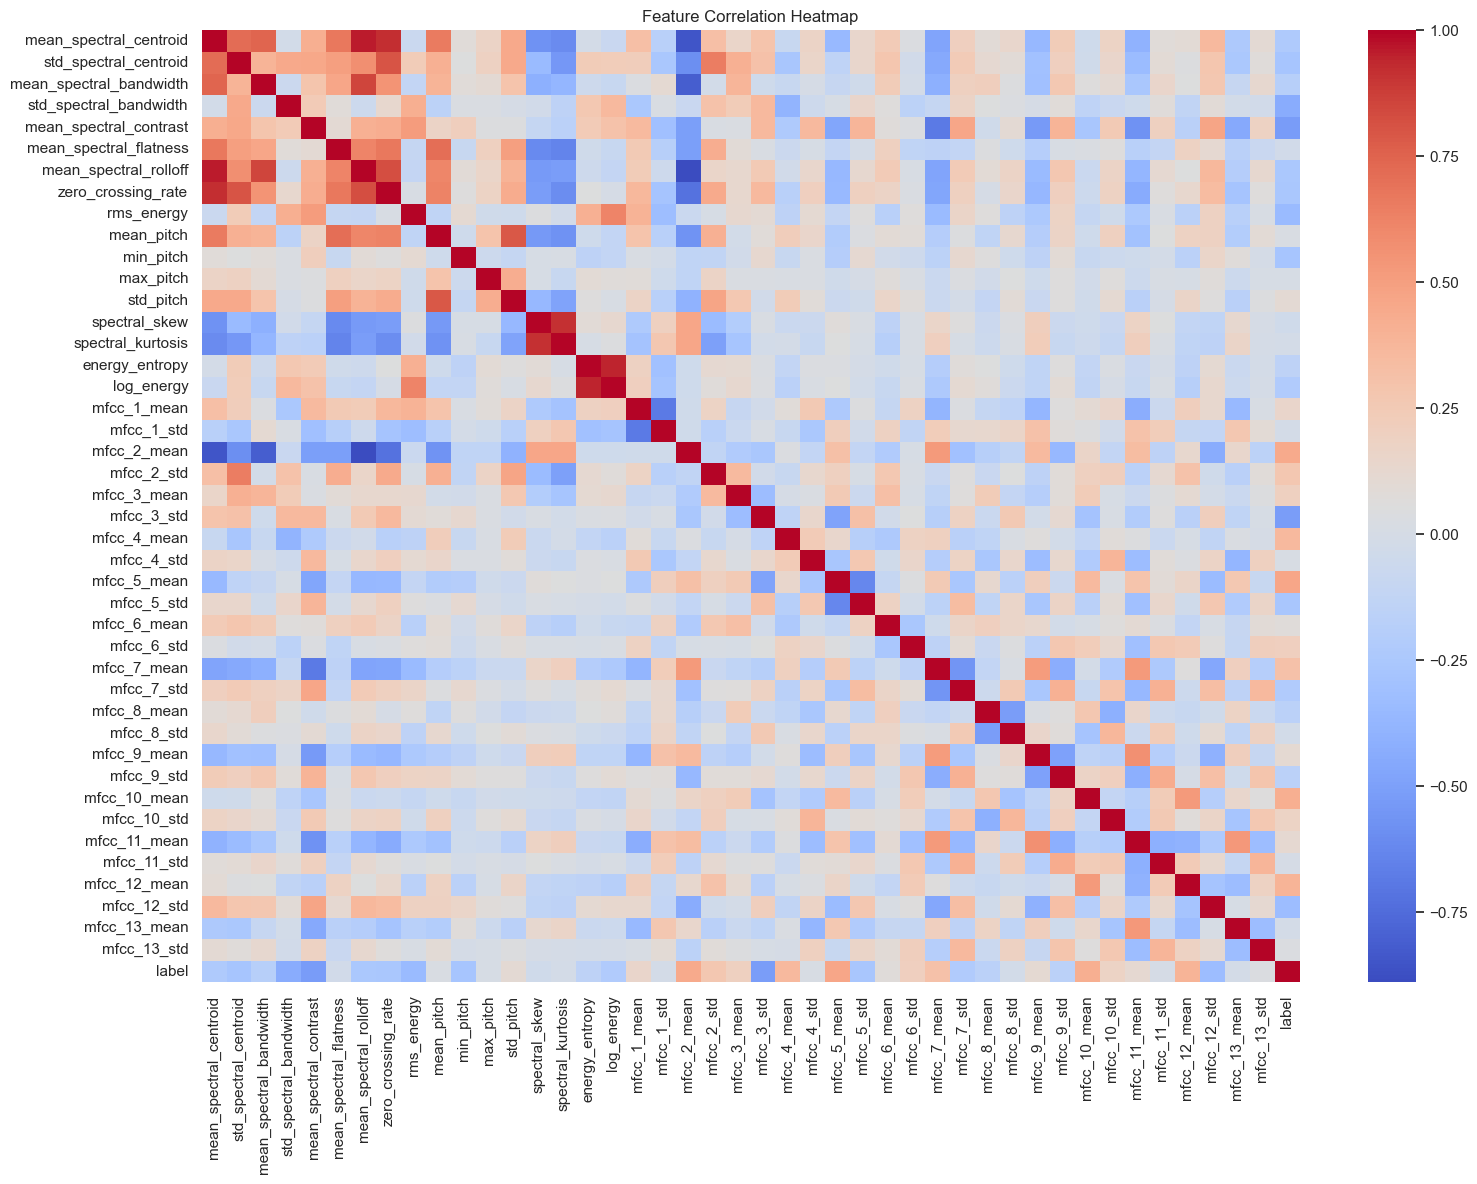

In [12]:
# 3. Correlation Heatmap (numeric features only)
plt.figure(figsize=(16, 12))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [13]:
corr = df.corr()['label'].sort_values(ascending=False)

# print(corr.head(10))
# print(corr.tail(10))
print(corr)

label                      1.000000
mfcc_5_mean                0.466618
mfcc_2_mean                0.444837
mfcc_10_mean               0.419576
mfcc_12_mean               0.393679
mfcc_4_mean                0.360128
mfcc_7_mean                0.309477
mfcc_2_std                 0.273513
mfcc_6_std                 0.209052
mfcc_3_mean                0.199473
mfcc_10_std                0.173989
mfcc_1_mean                0.150729
mfcc_11_mean               0.121335
mfcc_9_mean                0.109340
std_pitch                  0.102551
mfcc_6_mean                0.075279
mfcc_13_std                0.035133
mean_pitch                 0.019928
mfcc_4_std                 0.011428
max_pitch                  0.006378
mfcc_11_std               -0.001275
spectral_kurtosis         -0.012169
mfcc_1_std                -0.016557
mfcc_13_mean              -0.017860
mfcc_8_std                -0.025114
mean_spectral_flatness    -0.027926
spectral_skew             -0.036528
energy_entropy            -0

C:\Users\shubh\AppData\Local\Temp\ipykernel_17280\3099090345.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['label'] == 0][feature], label='Female (0)', shade=True)
C:\Users\shubh\AppData\Local\Temp\ipykernel_17280\3099090345.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['label'] == 1][feature], label='Male (1)', shade=True)


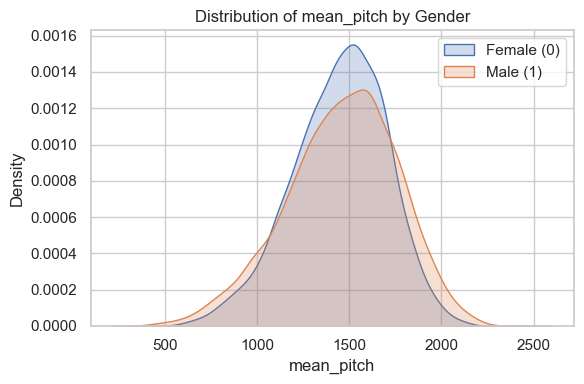

C:\Users\shubh\AppData\Local\Temp\ipykernel_17280\3099090345.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['label'] == 0][feature], label='Female (0)', shade=True)
C:\Users\shubh\AppData\Local\Temp\ipykernel_17280\3099090345.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['label'] == 1][feature], label='Male (1)', shade=True)


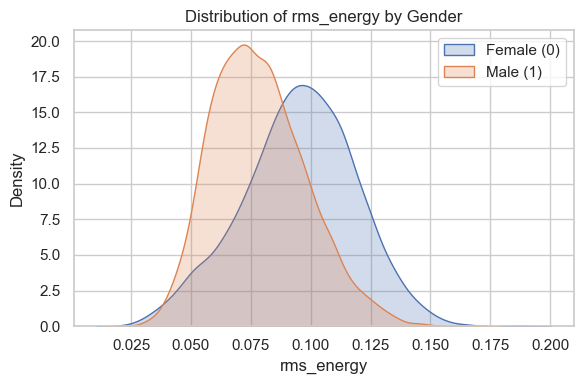

C:\Users\shubh\AppData\Local\Temp\ipykernel_17280\3099090345.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['label'] == 0][feature], label='Female (0)', shade=True)
C:\Users\shubh\AppData\Local\Temp\ipykernel_17280\3099090345.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['label'] == 1][feature], label='Male (1)', shade=True)


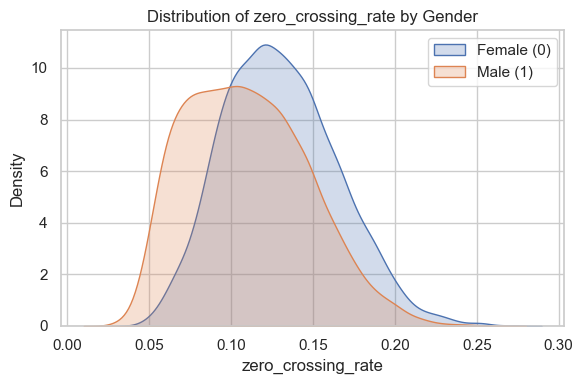

C:\Users\shubh\AppData\Local\Temp\ipykernel_17280\3099090345.py:6: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['label'] == 0][feature], label='Female (0)', shade=True)
C:\Users\shubh\AppData\Local\Temp\ipykernel_17280\3099090345.py:7: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df[df['label'] == 1][feature], label='Male (1)', shade=True)


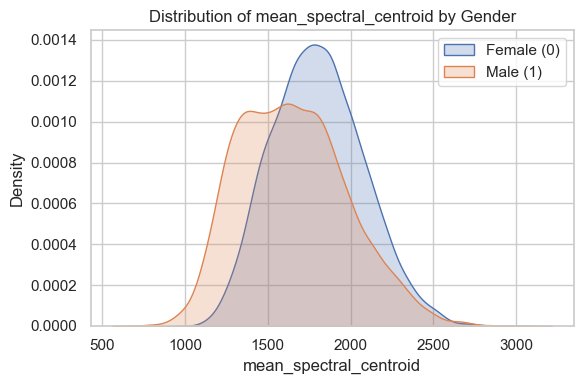

In [ ]:
import os

# create folder if not exists
os.makedirs("../reports/figures", exist_ok=True)

# KDE plots for selected features
selected_features = ['mean_pitch', 'rms_energy', 'zero_crossing_rate', 'mean_spectral_centroid']

for feature in selected_features:
    plt.figure(figsize=(6, 4))

    sns.kdeplot(df[df['label'] == 0][feature], label='Female (0)', shade=True)
    sns.kdeplot(df[df['label'] == 1][feature], label='Male (1)', shade=True)

    plt.title(f'Distribution of {feature} by Gender')
    plt.xlabel(feature)
    plt.legend()
    plt.tight_layout()
    plt.show()

    save_path = f"../reports/figures/{feature}_kde.png"
    plt.savefig(save_path)
    
    plt.close()

In [ ]:
# Optional: Boxplots for outlier detection
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[selected_features])
plt.title("Boxplot of Selected Features")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
for col in df.columns[:10]:  # first 10 features
    sns.boxplot(x='label', y=col, data=df)
    plt.title(f"{col} vs Gender")
    plt.show()

In [ ]:
selected_features = ['mean_pitch', 'rms_energy', 'label', 'zero_crossing_rate', 'mean_spectral_centroid']

sns.pairplot(df[selected_features], hue='label')
plt.show()
plt.savefig(r"../reports/figures/pairplot.png")

### Distribution by Gender

In [ ]:
features = ['mean_pitch', 'rms_energy', 'mean_spectral_centroid']

for feature in features:
    sns.kdeplot(data=df, x=feature, hue='label', fill=True)
    plt.title(f"{feature} Distribution by Gender")
    plt.show()

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [6]:
# 1. Split features and target
X = df.drop('label', axis=1)
y = df['label']

In [7]:
# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (11303, 43), Test shape: (4845, 43)


In [8]:
# 3. Feature Scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Optionally convert back to DataFrame for easy viewing
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

In [10]:
# Confirm scaling
X_train_scaled_df.describe().T[['mean', 'std']].head()

,mean,std
mean_spectral_centroid,-4.214977e-16,1.000044
std_spectral_centroid,-6.946383e-17,1.000044
mean_spectral_bandwidth,3.349037e-16,1.000044
std_spectral_bandwidth,-2.250503e-16,1.000044
mean_spectral_contrast,-1.868294e-15,1.000044


In [11]:
# Remove duplicates (if not already done)
df = df.drop_duplicates()

# Save to CSV
df.to_csv(r'../data/processed/vocal_gender_features_cleaned.csv', index=False)
print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
